# K-Means Clustering Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

#### Reading the cleaned dataset

In [2]:
sys.path.append('..')

from src.data import load_data
df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

#### Scaling the data using StandardScaler

In [4]:
features = ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 2.        ,  3.        ,  9.44699227, ...,  5.37063803,
         7.89170466,  7.19967835],
       [ 2.        ,  3.        ,  8.861917  , ...,  7.47477218,
         8.09985791,  7.48268183],
       [ 2.        ,  3.        ,  8.75683981, ...,  7.7857209 ,
         8.16536363,  8.96763167],
       ...,
       [ 1.        ,  3.        , 10.57717155, ...,  8.41427414,
         4.54329478,  7.7608932 ],
       [ 2.        ,  3.        ,  9.58410839, ...,  6.08221891,
         9.60521628,  7.53262362],
       [ 1.        ,  3.        ,  9.23902501, ...,  6.94601399,
         5.12989871,  7.66199756]], shape=(395, 8))

In [5]:
from src.clustering import kmeans_pipeline
model = kmeans_pipeline(X_data)

labels = model.predict(X_data)

Best K: 2
Best Silhouette Score: 0.3105


Text(0.5, 1.0, 'K-Means Clustering')

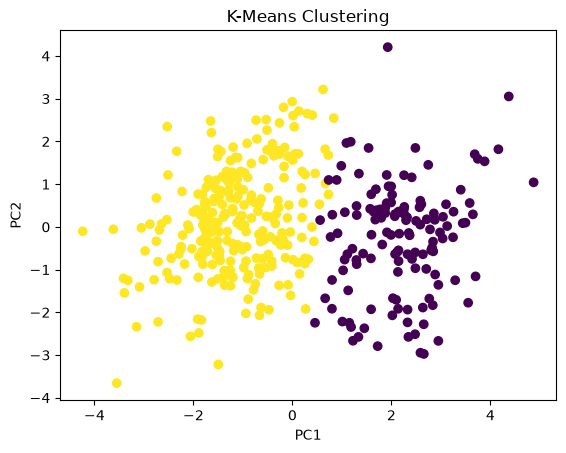

In [6]:
from sklearn.decomposition import PCA

X_scaled = model.named_steps["scaler"].transform(X_data)

pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[: , 0], X_pca[: , 1] , c = labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering')

## Conclusion

After evaluating K-Means with different numbers of clusters, the best result was obtained with **K = 2**, achieving a **Silhouette Score of 0.3105**.

This score indicates a relatively weak-to-moderate separation between the clusters. Therefore, while K-Means was able to identify some structure in the dataset, the resulting clusters are not strongly separated.

For this reason, the current K-Means model will be considered as a **baseline** for comparison with other clustering approaches. In the next stages, **Hierarchical Clustering** and **DBSCAN** will be evaluated. Additionally, K-Means, Hierarchical and DBSCAN will be applied after **PCA** to investigate whether dimensionality reduction can improve the clustering structure and evaluation metrics.
